# Introduction

**Federated Learning (FL)** enables multiple clients to train a model collaboratively without sharing raw data. Traditional **parallel FL** methods like **FedAvg** aggregate updates centrally, but can struggle with:

- Different client resources and network speeds  
- Dependence on a central server  

We use **Serial Federated Learning**, where the model is updated **cyclically** across clients. This avoids central aggregation but can cause **catastrophic forgetting**, where the model loses knowledge from previous clients.

To mitigate this, we implement **Cyclical Weight Consolidation (CWC)**:

**Difference from FedAvg:** CWC is sequential, reduces forgetting, and balances stability with adaptability, making it robust for heterogeneous, non-IID client datasets.
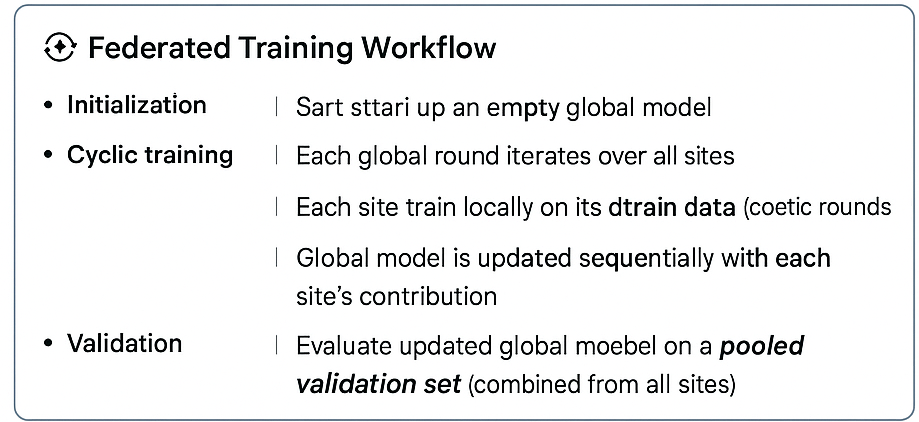

# Install & Imports

In [54]:
from IPython.display import clear_output

In [55]:
!pip install uv \
    Bio \
    codecarbon \
    shap 
clear_output()

In [56]:
import os
import math
import shap
import optuna
import random
import warnings
import kagglehub
import numpy as np
import pandas as pd
from Bio import SeqIO
import xgboost as xgb
import importlib.metadata
from itertools import product
from typing import List, Dict
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import log_loss
from scipy.stats import entropy#, gini
from codecarbon import EmissionsTracker
from concurrent.futures import ProcessPoolExecutor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold,train_test_split

# Environment Set-Up

In [57]:
# List of packages you actually use
packages = [
    "shap",
    "optuna",
    "numpy",
    "pandas",
    "biopython",  # for Bio.SeqIO
    "xgboost",
    "matplotlib",
    "scikit-learn",
    "scipy",
    "codecarbon"
]

with open("requirements.txt", "w") as f:
    for pkg in packages:
        try:
            version = importlib.metadata.version(pkg)
            f.write(f"{pkg}=={version}\n")
        except importlib.metadata.PackageNotFoundError:
            # package not installed
            f.write(f"{pkg}\n")

In [58]:
warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 50)
pd.set_option('display.max_rows', 10)
pd.set_option('display.max_columns', 100)

In [59]:
le = LabelEncoder()

- If you want to extract the raw features change Extract param to True. The train will take 4hrs to extract while test will take 2 hours. For now I have **train_more_feats.csv** and **test_more_feats.csv** ready for you,if you would not like to extract the features yourself.
-  Also, if you wanna tune the model like I did (takes roughly 15 minutes)

In [60]:
# -------------------------
# CONFIG
# -------------------------

Params={'Tune':False,
       'Extract': False,
       }

# Read Data

In [61]:
path = kagglehub.dataset_download("noob786/secondbatchoffastqfiles")
path = kagglehub.dataset_download("juliusmwangi/microbiome-classification-data")
path = kagglehub.dataset_download("noob786/mpeg-g-microbiomeclassificationconvertedfastqfiles")

In [62]:
# for folder, _, files in os.walk('/kaggle/input/'):
#     for f in files:
#         print(os.path.join(folder, f))

In [63]:
csv_path =r"/kaggle/input/microbiome-classification-data/Microbiome Classification Data"    # PATH TO VARIOUS CSVS

test_base_dirs = "/kaggle/input/mpeg-g-microbiomeclassificationconvertedfastqfiles/TestFiles/TestFiles"

train_base_dirs = [
    "/kaggle/input/mpeg-g-microbiomeclassificationconvertedfastqfiles/TrainFiles/TrainFiles/",
    "/kaggle/input/secondbatchoffastqfiles/TrainFiles"
]

In [64]:
# Read in csv files
train_df = pd.read_csv(csv_path + "/Train copy.csv")
test_df = pd.read_csv(csv_path + "/Test copy.csv")
train_subjects_df = pd.read_csv(csv_path + "/Train_Subjects.csv")
ss = pd.read_csv(csv_path + "/SampleSubmission.csv")
display(
       test_df.shape,
       test_df.head(2),
        ss.shape,
       ss.head(2),
       train_df.shape,
       train_df.head(2),
       train_subjects_df.shape,
       train_subjects_df.head(2),
)

(1068, 1)

,filename
0,ID_YBNOYC.mgb
1,ID_HPVLUO.mgb


(1068, 5)

,filename,Mouth,Nasal,Skin,Stool
0,ID_YBNOYC.mgb,0,0,0,0
1,ID_HPVLUO.mgb,0,0,0,0


(2901, 4)

,filename,SampleType,SubjectID,SampleID
0,ID_LETPJN.mgb,Stool,Subject_BCUNIB,Sample_AFTIWE
1,ID_NTDGIW.mgb,Stool,Subject_UDAXIH,Sample_JQJVNK


(66, 17)

,SubjectID,FPG_Mean,FPG_class,IRIS,SSPG,FPG,SSPG.Date,Class,Gender,Ethnicity,Adj.age,BMI,OGTT,OGTT_Class,Longitudinal.HbA1C.Group,A1C_Class,Family
0,Subject_UDAXIH,1.274432,Diabetes,IS,91.5,131.75,8/7/14,Diabetic,M,C,59.48,21.47,2.245,Diabetes,6. Variable Diabetic-PreDM (n = 8),6.VDP,NaN
1,Subject_NHOSIZ,0.915833,Normal,Unknown,NaN,NaN,NaN,Prediabetic,M,C,61.17,27.06,1.005,Normal,3. PreDM-to-Normal (n = 10),3.PN,NaN


In [65]:
test_df["filename"] = test_df["filename"].str.replace(".mgb", ".fastq", regex=False)
train_df["filename"] = train_df["filename"].str.replace(".mgb", ".fastq", regex=False)

# FASTQ Feature Extraction for Modeling

We extract a comprehensive set of features from FASTQ files to capture **read-level, compositional, complexity, and quality characteristics** for downstream modeling. Features include:

### 1. Read-Level Metrics
- **Number of reads (`num_reads`)** – indicates sequencing depth/coverage.  
- **Average read length (`avg_read_len`)** – reflects sequencing quality and library preparation.  
- **Read length variability (`read_len_std`, `read_len_min`, `read_len_max`)** – captures heterogeneity, edge cases, or mixed populations.  

### 2. GC Content & Nucleotide Composition
- **GC content (`gc_content`)** – species- or condition-specific genomic signature.  
- **GC variability (`gc_std`)** – detects sequencing bias or heterogeneity.  
- **Nucleotide proportions (`A`, `T`, `G`, `C`)** – capture composition biases.  

### 3. Sequence Complexity
- **Average Shannon entropy (`avg_entropy`)** – measures sequence diversity vs. repetitiveness; flags low-complexity or contaminated samples.  

### 4. Quality Metrics
- **Average base quality (`avg_quality`)** – overall sequencing reliability.  
- **Quality score variability (`std_quality`)** – flags inconsistent runs or sample prep issues.  

### 5. K-mer Frequencies
- **Dinucleotide and trinucleotide frequencies (`<kmer>_freq`)** – normalized counts for all possible k-mers, capturing sequence motifs and patterns.  

✅ These features provide a **robust statistical and biological foundation** for modeling, encoding sequencing depth, variability, composition, complexity, quality, and motifs.


In [66]:
def shannon_entropy(seq):
    counts = Counter(seq)
    probs = [c/len(seq) for c in counts.values() if len(seq) > 0]
    return -sum(p*math.log2(p) for p in probs)

def extract_features_from_fastq(path, k_values=[2,3]):
    total_reads = 0
    total_bases = 0
    sum_read_len = 0
    sum_read_len_sq = 0
    gc_total = 0
    gc_frac_sum = 0
    sum_entropy = 0
    quality_sum = 0
    quality_sq_sum = 0
    quality_count = 0
    
    nt_counter = Counter()
    kmer_counters = {k: Counter() for k in k_values}
    
    for record in SeqIO.parse(path, "fastq"):
        seq = str(record.seq)
        n = len(seq)
        if n == 0: 
            continue
        
        total_reads += 1
        total_bases += n
        sum_read_len += n
        sum_read_len_sq += n**2
        
        gc = seq.count("G") + seq.count("C")
        gc_total += gc
        gc_frac_sum += gc / n
        
        nt_counter.update(seq)
        ent = shannon_entropy(seq)
        sum_entropy += ent
        
        q = record.letter_annotations["phred_quality"]
        quality_sum += sum(q)
        quality_sq_sum += sum(v*v for v in q)
        quality_count += len(q)
        
        for k in k_values:
            kmer_counters[k].update(seq[i:i+k] for i in range(n-k+1))
    
    if total_reads == 0:
        return None

    feats = {
        "num_reads": total_reads,
        "avg_read_len": sum_read_len / total_reads,
        "read_len_std": math.sqrt(sum_read_len_sq/total_reads - (sum_read_len/total_reads)**2),
        "read_len_min": sum_read_len/total_reads if total_reads==1 else None,  # optional
        "read_len_max": None,  # skipped for streaming (could track separately)
        "gc_content": gc_total / total_bases,
        "gc_std": np.std([gc/l for gc,l in zip([gc_total],[total_bases])]),  # can approximate better
        "A": nt_counter["A"] / total_bases,
        "T": nt_counter["T"] / total_bases,
        "G": nt_counter["G"] / total_bases,
        "C": nt_counter["C"] / total_bases,
        "avg_entropy": sum_entropy / total_reads,
        "avg_quality": quality_sum / quality_count if quality_count else 0,
        "std_quality": math.sqrt(quality_sq_sum/quality_count - (quality_sum/quality_count)**2) if quality_count else 0,
    }
    
    for k in k_values:
        total_kmers = sum(kmer_counters[k].values())
        for mer in product("ACGT", repeat=k):
            mer = "".join(mer)
            feats[f"{mer}_freq"] = (
                kmer_counters[k][mer] / total_kmers if total_kmers else 0
            )
    
    return feats

In [67]:
### TEST
def process_test_row(row):
    fpath = os.path.join(test_base_dirs, row["filename"])
    feats = extract_features_from_fastq(fpath)
    if feats:
        feats["filename"] = row["filename"]
        return feats
    return None

In [68]:
%%time

# 2hrs 6gb cpu desktop

if Params['Extract']:
    #test_df = test_df.iloc[:5]  # test with fewer rows first
    
    with ProcessPoolExecutor() as ex:
        results = list(ex.map(process_test_row, [row for _, row in test_df.iterrows()]))
    
    test_features = [r for r in results if r]
    df_test = pd.DataFrame(test_features)
    
    df_test["ID"] = df_test["filename"].str.split(".").str[0]
    df_test.sort_values(by="ID", inplace=True)
    df_test.to_csv("test_more_feats.csv", index=False)
    display(df_test)

else:
    df_test = pd.read_csv('/kaggle/input/microbiome-classification-data/MoreFeatures/test_more_feats.csv')
    display(df_test)

,num_reads,avg_read_len,read_len_std,read_len_min,read_len_max,gc_content,gc_std,A,T,G,C,avg_entropy,avg_quality,std_quality,AA_freq,AC_freq,AG_freq,AT_freq,CA_freq,CC_freq,CG_freq,CT_freq,GA_freq,GC_freq,GG_freq,GT_freq,TA_freq,TC_freq,TG_freq,TT_freq,AAA_freq,AAC_freq,AAG_freq,AAT_freq,ACA_freq,ACC_freq,ACG_freq,ACT_freq,AGA_freq,AGC_freq,AGG_freq,AGT_freq,ATA_freq,ATC_freq,ATG_freq,ATT_freq,CAA_freq,CAC_freq,CAG_freq,CAT_freq,CCA_freq,CCC_freq,CCG_freq,CCT_freq,CGA_freq,CGC_freq,CGG_freq,CGT_freq,CTA_freq,CTC_freq,CTG_freq,CTT_freq,GAA_freq,GAC_freq,GAG_freq,GAT_freq,GCA_freq,GCC_freq,GCG_freq,GCT_freq,GGA_freq,GGC_freq,GGG_freq,GGT_freq,GTA_freq,GTC_freq,GTG_freq,GTT_freq,TAA_freq,TAC_freq,TAG_freq,TAT_freq,TCA_freq,TCC_freq,TCG_freq,TCT_freq,TGA_freq,TGC_freq,TGG_freq,TGT_freq,TTA_freq,TTC_freq,TTG_freq,TTT_freq,filename,ID
0,14618,400.0,0.0,NaN,NaN,0.562328,0.0,0.237991,0.199681,0.341668,0.220660,1.963627,36.385431,4.187551,0.060806,0.062861,0.067615,0.047146,0.049142,0.047000,0.070792,0.053052,0.080391,0.081445,0.123023,0.057188,0.047724,0.029905,0.079119,0.042791,0.010711,0.019300,0.019078,0.011779,0.013664,0.009816,0.025080,0.013945,0.011280,0.019572,0.019802,0.017098,0.013184,0.007521,0.018565,0.007972,0.013056,0.013421,0.013711,0.009065,0.011872,0.007331,0.011015,0.016847,0.015594,0.014108,0.032124,0.009094,0.011475,0.007955,0.019957,0.013672,0.020614,0.018007,0.022122,0.019826,0.020305,0.024267,0.021774,0.015301,0.030594,0.031130,0.038939,0.022286,0.015430,0.007885,0.025012,0.008645,0.016576,0.012274,0.012868,0.006094,0.003425,0.005705,0.013099,0.007092,0.021157,0.016839,0.032456,0.008853,0.007755,0.006620,0.015784,0.012605,ID_ABHFUP.fastq,ID_ABHFUP
1,18721,400.0,0.0,NaN,NaN,0.560986,0.0,0.240297,0.198717,0.340561,0.220425,1.962230,36.480077,4.073163,0.062127,0.066046,0.064898,0.046966,0.046842,0.046230,0.073687,0.053457,0.082983,0.081650,0.121011,0.055647,0.048862,0.027050,0.079399,0.043144,0.011432,0.022179,0.016037,0.011823,0.014031,0.010024,0.027902,0.013501,0.012161,0.020180,0.016488,0.016183,0.015744,0.005553,0.017765,0.008021,0.011952,0.012810,0.013470,0.008727,0.009593,0.005786,0.011194,0.019769,0.015636,0.014371,0.034647,0.009151,0.011183,0.007871,0.020413,0.013563,0.021077,0.019370,0.022263,0.020433,0.019272,0.024828,0.022850,0.014904,0.029647,0.029566,0.038829,0.023268,0.014118,0.006781,0.025371,0.009348,0.017819,0.011836,0.013287,0.006039,0.004064,0.005708,0.011925,0.005416,0.023332,0.017738,0.031342,0.007184,0.007941,0.006913,0.016049,0.012321,ID_ADBLNY.fastq,ID_ADBLNY
2,269026,124.5,0.5,NaN,NaN,0.522358,0.0,0.207287,0.270355,0.253496,0.268862,1.945659,34.630868,4.055200,0.051696,0.051570,0.058025,0.046241,0.053809,0.068011,0.074733,0.073970,0.047338,0.073001,0.063777,0.068838,0.056120,0.074410,0.059010,0.079451,0.012479,0.011036,0.015591,0.013011,0.006862,0.012528,0.017437,0.015013,0.008380,0.019369,0.014155,0.016515,0.007839,0.013453,0.005782,0.018912,0.008424,0.016114,0.017113,0.012557,0.014069,0.017084,0.016237,0.021176,0.008830,0.026277,0.016413,0.023818,0.015125,0.015427,0.020725,0.020412,0.016878,0.005686,0.016177,0.008983,0.015877,0.012728,0.023656,0.020973,0.018261,0.015286,0.017216,0.013533,0.012672,0.015863,0.017068,0.023744,0.014336,0.019154,0.009618,0.012068,0.017439,0.022151,0.018013,0.017409,0.012253,0.012664,0.016513,0.015532,0.016868,0.030273,0.015916,0.017031,ID_AFAEMB.fastq,ID_AFAEMB
3,157204,124.5,0.5,NaN,NaN,0.518889,0.0,0.208541,0.272569,0.252100,0.266789,1.947329,32.533559,6.075294,0.050784,0.053536,0.056802,0.047708,0.053192,0.066484,0.072634,0.075913,0.046848,0.073622,0.062713,0.068478,0.059400,0.071261,0.061991,0.078633,0.011799,0.011165,0.014630,0.013602,0.007769,0.013111,0.017456,0.015322,0.007321,0.019116,0.015367,0.015423,0.007231,0.013943,0.006946,0.019447,0.006836,0.016594,0.016677,0.013248,0.014680,0.017056,0.013374,0.021896,0.008538,0.024887,0.015775,0.024015,0.016326,0.015632,0.022532,0.019158,0.017085,0.004867,0.016370,0.008899,0.015295,0.011252,0.025438,0.021854,0.0

CPU times: user 99.8 ms, sys: 7.02 ms, total: 107 ms
Wall time: 108 ms


In [69]:
### TRAIN
def process_train_row(row):
    fname = row["filename"]

    # Normalize train_base_dirs into a list, even if it's a string
    bases = train_base_dirs if isinstance(train_base_dirs, (list, tuple)) else [train_base_dirs]

    fpath = None
    for base in bases:
        candidate = os.path.join(base, fname)
        if os.path.exists(candidate):
            fpath = candidate
            break

    if fpath is None:
        return None  # file not found in any base dir

    feats = extract_features_from_fastq(fpath)
    if feats:
        feats["filename"] = fname
        return feats
    return None

In [70]:
%%time
# 3HRS  57MINS

if Params['Extract']:
    #train_df=train_df[train_df['filename'].isin(['ID_QEUWDL.fastq','ID_AAFNOT.fastq'])] #for testing
    
    train_features = []
    with ProcessPoolExecutor() as ex:
        results = list(ex.map(process_train_row, [row for _, row in train_df.iterrows()]))
    
    train_features = [r for r in results if r]  # filter out None
    df_train = pd.DataFrame(train_features)
    
    df_train['ID']=df_train['filename'].apply(lambda x: x.split('.')[:1][0])
    df_train.sort_values(by='ID',inplace=True)
    df_train.to_csv("train_more_feats.csv",index=False)
    display(df_train)
else:
    df_train = pd.read_csv('/kaggle/input/microbiome-classification-data/MoreFeatures/train_more_feats.csv')
    display(df_train)

,num_reads,avg_read_len,read_len_std,read_len_min,read_len_max,gc_content,gc_std,A,T,G,C,avg_entropy,avg_quality,std_quality,AA_freq,AC_freq,AG_freq,AT_freq,CA_freq,CC_freq,CG_freq,CT_freq,GA_freq,GC_freq,GG_freq,GT_freq,TA_freq,TC_freq,TG_freq,TT_freq,AAA_freq,AAC_freq,AAG_freq,AAT_freq,ACA_freq,ACC_freq,ACG_freq,ACT_freq,AGA_freq,AGC_freq,AGG_freq,AGT_freq,ATA_freq,ATC_freq,ATG_freq,ATT_freq,CAA_freq,CAC_freq,CAG_freq,CAT_freq,CCA_freq,CCC_freq,CCG_freq,CCT_freq,CGA_freq,CGC_freq,CGG_freq,CGT_freq,CTA_freq,CTC_freq,CTG_freq,CTT_freq,GAA_freq,GAC_freq,GAG_freq,GAT_freq,GCA_freq,GCC_freq,GCG_freq,GCT_freq,GGA_freq,GGC_freq,GGG_freq,GGT_freq,GTA_freq,GTC_freq,GTG_freq,GTT_freq,TAA_freq,TAC_freq,TAG_freq,TAT_freq,TCA_freq,TCC_freq,TCG_freq,TCT_freq,TGA_freq,TGC_freq,TGG_freq,TGT_freq,TTA_freq,TTC_freq,TTG_freq,TTT_freq,filename,label,ID
0,42840,124.5,0.5,NaN,NaN,0.552629,0.0,0.182194,0.265177,0.268545,0.284083,1.920269,33.814612,5.260114,0.042977,0.042083,0.053192,0.042267,0.048329,0.086290,0.077074,0.074589,0.053084,0.072132,0.076118,0.068617,0.039265,0.081836,0.064273,0.077874,0.011399,0.009149,0.013774,0.008986,0.003884,0.015486,0.012330,0.010724,0.008209,0.013395,0.024267,0.007750,0.007140,0.013177,0.002331,0.019952,0.002524,0.018687,0.016994,0.010508,0.026537,0.022126,0.012268,0.026061,0.006587,0.031601,0.012660,0.026838,0.002638,0.025675,0.020815,0.022066,0.017881,0.004217,0.014414,0.014143,0.006709,0.012391,0.028534,0.025073,0.020147,0.016368,0.021112,0.019107,0.015467,0.013305,0.020158,0.020177,0.011515,0.010369,0.008445,0.008975,0.011589,0.032926,0.024570,0.013337,0.018514,0.011355,0.018700,0.015479,0.010335,0.030344,0.021493,0.016315,ID_AAFNOT.fastq,Mouth,ID_AAFNOT
1,42814,400.0,0.0,NaN,NaN,0.539853,0.0,0.268928,0.191218,0.316762,0.223092,1.970735,36.432308,4.110366,0.068139,0.069039,0.075684,0.055772,0.059831,0.050969,0.066888,0.045795,0.090766,0.072336,0.104082,0.049873,0.050760,0.031305,0.068506,0.040255,0.012121,0.025302,0.019065,0.011652,0.018307,0.014046,0.025362,0.011469,0.018427,0.018038,0.021356,0.017933,0.014461,0.006695,0.020634,0.013861,0.015172,0.014303,0.016626,0.013879,0.013895,0.010529,0.012493,0.014112,0.016406,0.015687,0.025184,0.009728,0.011870,0.006757,0.017628,0.009548,0.023510,0.020072,0.025770,0.021247,0.022142,0.017390,0.019544,0.013428,0.027356,0.025066,0.032572,0.019173,0.013679,0.010128,0.016871,0.008967,0.017470,0.009520,0.014413,0.009081,0.005637,0.009132,0.009655,0.006901,0.026414,0.013726,0.025222,0.003164,0.010878,0.007803,0.013543,0.007980,ID_AAXPTO.fastq,Nasal,ID_AAXPTO
2,21794,400.0,0.0,NaN,NaN,0.543314,0.0,0.264808,0.191878,0.318555,0.224759,1.971770,36.337955,4.253057,0.069275,0.069648,0.069764,0.055304,0.060445,0.051477,0.067573,0.045804,0.088762,0.075506,0.104659,0.050137,0.046960,0.028691,0.074889,0.041107,0.014410,0.026495,0.017206,0.010976,0.019197,0.014546,0.024091,0.011988,0.015363,0.018286,0.018402,0.017703,0.013215,0.005343,0.021327,0.015179,0.013021,0.015215,0.018268,0.014091,0.013562,0.010740,0.013731,0.013568,0.016135,0.015508,0.026591,0.009498,0.010107,0.006470,0.019173,0.009965,0.023997,0.018881,0.022870,0.022380,0.022837,0.017515,0.021418,0.013916,0.026368,0.025725,0.033165,0.019638,0.013471,0.008589,0.020397,0.007797,0.018019,0.009228,0.011595,0.007970,0.004999,0.008805,0.008503,0.006447,0.028653,0.016177,0.026757,0.003423,0.010280,0.008361,0.014178,0.008270,ID_AAYKAN.fastq,Nasal,ID_AAYKAN
3,448014,124.5,0.5,NaN,NaN,0.529188,0.0,0.203929,0.266883,0.255616,0.273572,1.931284,33.422338,5.076070,0.055281,0.047889,0.055491,0.044704,0.054865,0.075711,0.074520,0.070679,0.049232,0.071115,0.067452,0.068245,0.046199,0.077024,0.060221,0.081374,0.018263,0.010775,0.017159,0.009046,0.007113,0.014898,0.012652,0.013616,0.009215,0.014861,0.020643,0.011138,0.007744,0.012551,0.004707,0.020053,0.004272,0.021157,0.016460,0.013410,0.025223,0.016028,0.012923,0.022155,0.004418,0.030490,0.013117,0.027099,0.006994,0.020627,0.018719,0.021358,0.020723,0.003880,0.011733,0.011575,0.008092,0.01165

CPU times: user 158 ms, sys: 14.9 ms, total: 173 ms
Wall time: 175 ms


In [71]:
train_df['ID']=train_df['filename'].apply(lambda x: x.split('.')[:1][0])
train_df.sort_values(by='ID',inplace=True)
train_df.drop(columns='filename',inplace=True)

df_train=df_train.merge(train_df,on='ID',how='left')
df_train.drop(columns='label',inplace=True)
df_train

,num_reads,avg_read_len,read_len_std,read_len_min,read_len_max,gc_content,gc_std,A,T,G,C,avg_entropy,avg_quality,std_quality,AA_freq,AC_freq,AG_freq,AT_freq,CA_freq,CC_freq,CG_freq,CT_freq,GA_freq,GC_freq,GG_freq,GT_freq,TA_freq,TC_freq,TG_freq,TT_freq,AAA_freq,AAC_freq,AAG_freq,AAT_freq,ACA_freq,ACC_freq,ACG_freq,ACT_freq,AGA_freq,AGC_freq,AGG_freq,AGT_freq,ATA_freq,ATC_freq,ATG_freq,ATT_freq,CAA_freq,CAC_freq,CAG_freq,CAT_freq,CCA_freq,CCC_freq,CCG_freq,CCT_freq,CGA_freq,CGC_freq,CGG_freq,CGT_freq,CTA_freq,CTC_freq,CTG_freq,CTT_freq,GAA_freq,GAC_freq,GAG_freq,GAT_freq,GCA_freq,GCC_freq,GCG_freq,GCT_freq,GGA_freq,GGC_freq,GGG_freq,GGT_freq,GTA_freq,GTC_freq,GTG_freq,GTT_freq,TAA_freq,TAC_freq,TAG_freq,TAT_freq,TCA_freq,TCC_freq,TCG_freq,TCT_freq,TGA_freq,TGC_freq,TGG_freq,TGT_freq,TTA_freq,TTC_freq,TTG_freq,TTT_freq,filename,ID,SampleType,SubjectID,SampleID
0,42840,124.5,0.5,NaN,NaN,0.552629,0.0,0.182194,0.265177,0.268545,0.284083,1.920269,33.814612,5.260114,0.042977,0.042083,0.053192,0.042267,0.048329,0.086290,0.077074,0.074589,0.053084,0.072132,0.076118,0.068617,0.039265,0.081836,0.064273,0.077874,0.011399,0.009149,0.013774,0.008986,0.003884,0.015486,0.012330,0.010724,0.008209,0.013395,0.024267,0.007750,0.007140,0.013177,0.002331,0.019952,0.002524,0.018687,0.016994,0.010508,0.026537,0.022126,0.012268,0.026061,0.006587,0.031601,0.012660,0.026838,0.002638,0.025675,0.020815,0.022066,0.017881,0.004217,0.014414,0.014143,0.006709,0.012391,0.028534,0.025073,0.020147,0.016368,0.021112,0.019107,0.015467,0.013305,0.020158,0.020177,0.011515,0.010369,0.008445,0.008975,0.011589,0.032926,0.024570,0.013337,0.018514,0.011355,0.018700,0.015479,0.010335,0.030344,0.021493,0.016315,ID_AAFNOT.fastq,ID_AAFNOT,Skin,Subject_TQDMSG,Sample_PKCWPK
1,42814,400.0,0.0,NaN,NaN,0.539853,0.0,0.268928,0.191218,0.316762,0.223092,1.970735,36.432308,4.110366,0.068139,0.069039,0.075684,0.055772,0.059831,0.050969,0.066888,0.045795,0.090766,0.072336,0.104082,0.049873,0.050760,0.031305,0.068506,0.040255,0.012121,0.025302,0.019065,0.011652,0.018307,0.014046,0.025362,0.011469,0.018427,0.018038,0.021356,0.017933,0.014461,0.006695,0.020634,0.013861,0.015172,0.014303,0.016626,0.013879,0.013895,0.010529,0.012493,0.014112,0.016406,0.015687,0.025184,0.009728,0.011870,0.006757,0.017628,0.009548,0.023510,0.020072,0.025770,0.021247,0.022142,0.017390,0.019544,0.013428,0.027356,0.025066,0.032572,0.019173,0.013679,0.010128,0.016871,0.008967,0.017470,0.009520,0.014413,0.009081,0.005637,0.009132,0.009655,0.006901,0.026414,0.013726,0.025222,0.003164,0.010878,0.007803,0.013543,0.007980,ID_AAXPTO.fastq,ID_AAXPTO,Stool,Subject_UDAXIH,Sample_SCJCMW
2,21794,400.0,0.0,NaN,NaN,0.543314,0.0,0.264808,0.191878,0.318555,0.224759,1.971770,36.337955,4.253057,0.069275,0.069648,0.069764,0.055304,0.060445,0.051477,0.067573,0.045804,0.088762,0.075506,0.104659,0.050137,0.046960,0.028691,0.074889,0.041107,0.014410,0.026495,0.017206,0.010976,0.019197,0.014546,0.024091,0.011988,0.015363,0.018286,0.018402,0.017703,0.013215,0.005343,0.021327,0.015179,0.013021,0.015215,0.018268,0.014091,0.013562,0.010740,0.013731,0.013568,0.016135,0.015508,0.026591,0.009498,0.010107,0.006470,0.019173,0.009965,0.023997,0.018881,0.022870,0.022380,0.022837,0.017515,0.021418,0.013916,0.026368,0.025725,0.033165,0.019638,0.013471,0.008589,0.020397,0.007797,0.018019,0.009228,0.011595,0.007970,0.004999,0.008805,0.008503,0.006447,0.028653,0.016177,0.026757,0.003423,0.010280,0.008361,0.014178,0.008270,ID_AAYKAN.fastq,ID_AAYKAN,Stool,Subject_YXWGWJ,Sample_PAHSXW
3,448014,124.5,0.5,NaN,NaN,0.529188,0.0,0.203929,0.266883,0.255616,0.273572,1.931284,33.422338,5.076070,0.055281,0.047889,0.055491,0.044704,0.054865,0.075711,0.074520,0.070679,0.049232,0.071115,0.067452,0.068245,0.046199,0.077024,0.060221,0.081374,0.018263,0.010775,0.017159,0.009046,0.007113,0.014898,0.012652,0.013616,0.009215,0.014861,0.020643,0.011138,0.007744,0.012551,0.004707,0.020053,0.004272,0.021157,0.016460,0.013410,0.025223,0.016028,0.012923,0.022155,0.004418,0.030

# 📊 Feature Engineering

I hand engineered several biologically meaningful and statistical features to enhance classification. Without them, my CV worsened to 0.04 from 0.03. Also the private leaderboard worsens to 0.021 from 0.020:

---

### 1. Nucleotide Balance and Skew Features
- **AT/GC ratio** – balance of AT vs GC bases  
- **Purine/Pyrimidine ratio** – balance of A+G vs C+T  
- **GC skew** – asymmetry between G and C  
- **AT skew** – asymmetry between A and T  

---

### 2. K-mer Diversity Metrics
- **Shannon entropy** of k-mer distribution (k = 2, 3)  
- **Gini coefficient** to capture inequality in k-mer usage  
- **Common k-mer count** (above frequency threshold)  
- **Maximum k-mer frequency**  
- **Coefficient of variation** of k-mer frequencies  

---

### 3. Stop Codon and Biological Significance Features
- Frequencies of **stop codons** (TAA, TAG, TGA)  
- **Total stop codon frequency**  
- **Start codon ATG frequency**  
- **CpG-related ratio** (CG dinucleotide frequency vs C·G product)  

---

### 4. Interaction and Polynomial Features
- Pairwise **interactions** between key base features  
- **Squared terms** and polynomial combinations (degree 2)  
- Captures nonlinear relationships between GC content, read length, quality, and base counts  

---

### 5. Read Length Distribution Features
- **Coefficient of variation** of read length  
- **Read length to quality ratio**  
- **Total sequenced bases** (num_reads × avg_read_len)  

---

### 6. Quality Distribution Features
- **Quality-to-entropy ratio**  
- **Signal-to-noise ratio** (mean/std of quality scores)  

---

✅ These engineered features capture **sequence composition, diversity, functional motifs, statistical variation, and quality signals** that may be relevant for downstream classification.


In [72]:
#1. Nucleotide Balance and Skew Features
# These capture imbalances between complementary nucleotides, which can be biologically significant.

# Calculate ratios and skews
def add_balance_features(df):
    df = df.copy()
    # AT/GC Ratio
    df['AT_GC_ratio'] = (df['A'] + df['T']) / (df['G'] + df['C']).replace(0, np.nan)
    
    # Purine (A,G) vs Pyrimidine (C,T) ratio
    df['purine_pyr_ratio'] = (df['A'] + df['G']) / (df['C'] + df['T']).replace(0, np.nan)
    
    # GC Skew - measures strand asymmetry
    df['GC_skew'] = (df['G'] - df['C']) / (df['G'] + df['C']).replace(0, np.nan)
    
    # AT Skew
    df['AT_skew'] = (df['A'] - df['T']) / (df['A'] + df['T']).replace(0, np.nan)
    
    # Fill any NaN values created by division by zero
    df = df.fillna(0)
    return df

# Apply to both dataframes
#df_train = add_balance_features(df_train)
#df_test = add_balance_features(df_test)

def gini(array):
    """Compute Gini coefficient of a numpy array."""
    array = np.array(array, dtype=np.float64)
    if np.amin(array) < 0:
        array -= np.amin(array)  # make all values non-negative
    array += 1e-8  # avoid division by zero
    array = np.sort(array)
    n = array.size
    index = np.arange(1, n + 1)
    return (np.sum((2 * index - n - 1) * array)) / (n * np.sum(array))


# 2. K-mer Diversity Metrics
# Create features that describe the distribution of k-mers rather than just individual frequencies.

def add_kmer_diversity_features(df, k_values=[2, 3]):
    df = df.copy()
    
    for k in k_values:
        # Get all k-mer columns for this k value
        kmer_cols = [col for col in df.columns if col.endswith(f'_freq') and len(col.split('_')[0]) == k]
        
        if not kmer_cols:
            continue
            
        kmer_matrix = df[kmer_cols].values
        
        # 1. Shannon Entropy of k-mer distribution
        df[f'{k}mer_entropy'] = [entropy(row) for row in kmer_matrix]
        
        # 2. Gini Impurity (measure of inequality in distribution)
        df[f'{k}mer_gini'] = [gini(row) for row in kmer_matrix]
        
        # 3. Number of "common" k-mers (above threshold)
        df[f'{k}mer_common_count'] = (kmer_matrix > 0.01).sum(axis=1)
        
        # 4. Maximum k-mer frequency
        df[f'{k}mer_max_freq'] = kmer_matrix.max(axis=1)
        
        # 5. Coefficient of variation of k-mer frequencies
        with np.errstate(divide='ignore', invalid='ignore'):
            cv = np.std(kmer_matrix, axis=1) / np.mean(kmer_matrix, axis=1)
        df[f'{k}mer_cv'] = np.nan_to_num(cv, nan=0.0, posinf=0.0, neginf=0.0)
    
    return df

#df_train = add_kmer_diversity_features(df_train)
#df_test = add_kmer_diversity_features(df_test)

# 3. Stop Codon and Biological Significance Features
def add_biological_features(df):
    df = df.copy()
    
    # Stop codon frequencies (TAA, TAG, TGA)
    stop_codons = ['TAA', 'TAG', 'TGA']
    for codon in stop_codons:
        if f'{codon}_freq' in df.columns:
            df[f'stop_{codon}'] = df[f'{codon}_freq']
    
    # Total stop codon frequency
    stop_cols = [f'stop_{codon}' for codon in stop_codons if f'stop_{codon}' in df.columns]
    if stop_cols:
        df['total_stop_freq'] = df[stop_cols].sum(axis=1)
    
    # Start codon frequency (ATG)
    if 'ATG_freq' in df.columns:
        df['start_ATG_freq'] = df['ATG_freq']
    
    # CpG island related (CG frequency)
    if 'CG_freq' in df.columns:
        df['CG_ratio'] = df['CG_freq'] / (df['C'] * df['G']).replace(0, np.nan)
        df['CG_ratio'] = df['CG_ratio'].fillna(0)
    
    return df

#df_train = add_biological_features(df_train)
#df_test = add_biological_features(df_test)

# 4. Interaction and Polynomial Features
# Create features that capture interactions between your most important base features.

def add_interaction_features(df):
    df = df.copy()
    
    # Select base features for interactions
    base_features = ['gc_content', 'avg_read_len', 'avg_quality', 'avg_entropy', 
                    'num_reads', 'A', 'T', 'G', 'C']
    
    # Keep only features that exist in dataframe
    base_features = [f for f in base_features if f in df.columns]
    
    if base_features:
        # Create polynomial features (degree 2)
        poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
        poly_features = poly.fit_transform(df[base_features])
        
        # Create meaningful names
        feature_names = []
        for i, feat in enumerate(base_features):
            for j, feat2 in enumerate(base_features):
                if i <= j:  # Avoid duplicates
                    if i == j:
                        feature_names.append(f'{feat}^2')
                    else:
                        feature_names.append(f'{feat}*{feat2}')
        
        # Add to dataframe
        poly_df = pd.DataFrame(poly_features[:, len(base_features):], 
                              columns=feature_names, 
                              index=df.index)
        df = pd.concat([df, poly_df], axis=1)
    
    return df

#df_train = add_interaction_features(df_train)
#df_test = add_interaction_features(df_test)

# 5. Read Length Distribution Features
# Enhance your read length statistics.

def add_read_length_features(df):
    df = df.copy()
    
    # Coefficient of variation of read length
    df['read_len_cv'] = df['read_len_std'] / df['avg_read_len'].replace(0, np.nan)
    df['read_len_cv'] = df['read_len_cv'].fillna(0)
    
    # Read length to quality ratio
    df['read_len_quality_ratio'] = df['avg_read_len'] / df['avg_quality'].replace(0, np.nan)
    df['read_len_quality_ratio'] = df['read_len_quality_ratio'].fillna(0)
    
    # Total sequenced bases
    df['total_bases'] = df['num_reads'] * df['avg_read_len']
    
    return df

#df_train = add_read_length_features(df_train)
#df_test = add_read_length_features(df_test)

# 6. Quality Distribution Features
def add_quality_features(df):
    df = df.copy()
    
    # Quality to entropy ratio
    df['quality_entropy_ratio'] = df['avg_quality'] / df['avg_entropy'].replace(0, np.nan)
    df['quality_entropy_ratio'] = df['quality_entropy_ratio'].fillna(0)
    
    # Signal to noise ratio (mean/std of quality)
    df['quality_snr'] = df['avg_quality'] / df['std_quality'].replace(0, np.nan)
    df['quality_snr'] = df['quality_snr'].fillna(0)
    
    return df

#df_train = add_quality_features(df_train)
#df_test = add_quality_features(df_test)

In [73]:
#7. Apply All Feature Engineering
#Apply all feature engineering steps in sequence

def engineer_all_features(df):
    df = add_balance_features(df)
    df = add_kmer_diversity_features(df)
    df = add_biological_features(df)
    df = add_read_length_features(df)
    df = add_quality_features(df)
    #df = add_interaction_features(df)  # Do this last as it creates many features
    return df

# Apply to both datasets
df_train = engineer_all_features(df_train)
df_test = engineer_all_features(df_test)
#print(f"Original features: {len(df_train.columns)}")
#print(f"Enhanced features: {len(df_train_enhanced.columns)}")
#print(f"New features added: {len(df_train_enhanced.columns) - len(df_train.columns)}")

# Client Data Preparation

Each client dataset is derived from the **`Class` column**, which encodes a **composite phenotype** that integrates **glucose** and **insulin** information.  

---

## 🔹 Classes Represent
- **Control** → baseline healthy group  
- **Crossover** → transitional metabolic state  
- **Diabetic** → diagnosed diabetes phenotype  
- **Prediabetic** → early metabolic risk group  

---

## 📂 Preparation Steps
1. **Normalize labels**  
   - The `label` column is cast to string for consistency.

2. **Identify sites**  
   - Unique values in the `Class` column define the sites:  
     `['Control', 'Crossover', 'Diabetic', 'Prediabetic']`.

3. **Create per-site datasets**  
   - For each site:
     - Subset rows where `Class == site`.  
     - Save to `DATA_ROOT/<site>/<site>_train.csv`.

---

✅ This ensures that **each phenotype group is treated as a separate client dataset**, while preserving its biological meaning (glucose–insulin composite state).


In [74]:
df_train=df_train.merge(train_subjects_df[['SubjectID','Class']],on='SubjectID',how='left')
df_train.drop(columns='SubjectID',inplace=True)
df_train["label"] = le.fit_transform(df_train["SampleType"])
df_train.head(3)

,num_reads,avg_read_len,read_len_std,read_len_min,read_len_max,gc_content,gc_std,A,T,G,C,avg_entropy,avg_quality,std_quality,AA_freq,AC_freq,AG_freq,AT_freq,CA_freq,CC_freq,CG_freq,CT_freq,GA_freq,GC_freq,GG_freq,GT_freq,TA_freq,TC_freq,TG_freq,TT_freq,AAA_freq,AAC_freq,AAG_freq,AAT_freq,ACA_freq,ACC_freq,ACG_freq,ACT_freq,AGA_freq,AGC_freq,AGG_freq,AGT_freq,ATA_freq,ATC_freq,ATG_freq,ATT_freq,CAA_freq,CAC_freq,CAG_freq,CAT_freq,...,GTC_freq,GTG_freq,GTT_freq,TAA_freq,TAC_freq,TAG_freq,TAT_freq,TCA_freq,TCC_freq,TCG_freq,TCT_freq,TGA_freq,TGC_freq,TGG_freq,TGT_freq,TTA_freq,TTC_freq,TTG_freq,TTT_freq,filename,ID,SampleType,SampleID,AT_GC_ratio,purine_pyr_ratio,GC_skew,AT_skew,2mer_entropy,2mer_gini,2mer_common_count,2mer_max_freq,2mer_cv,3mer_entropy,3mer_gini,3mer_common_count,3mer_max_freq,3mer_cv,stop_TAA,stop_TAG,stop_TGA,total_stop_freq,start_ATG_freq,CG_ratio,read_len_cv,read_len_quality_ratio,total_bases,quality_entropy_ratio,quality_snr,Class,label
0,42840,124.5,0.5,0.0,0.0,0.552629,0.0,0.182194,0.265177,0.268545,0.284083,1.920269,33.814612,5.260114,0.042977,0.042083,0.053192,0.042267,0.048329,0.086290,0.077074,0.074589,0.053084,0.072132,0.076118,0.068617,0.039265,0.081836,0.064273,0.077874,0.011399,0.009149,0.013774,0.008986,0.003884,0.015486,0.012330,0.010724,0.008209,0.013395,0.024267,0.007750,0.007140,0.013177,0.002331,0.019952,0.002524,0.018687,0.016994,0.010508,...,0.013305,0.020158,0.020177,0.011515,0.010369,0.008445,0.008975,0.011589,0.032926,0.024570,0.013337,0.018514,0.011355,0.018700,0.015479,0.010335,0.030344,0.021493,0.016315,ID_AAFNOT.fastq,ID_AAFNOT,Skin,Sample_PKCWPK,0.809533,0.820630,-0.028116,-0.185490,2.739876,0.142746,16,0.086290,0.252251,4.040695,0.268805,50,0.032926,0.473400,0.011515,0.008445,0.018514,0.038474,0.002331,1.010283,0.004016,3.681840,5333580.0,17.609307,6.428494,Prediabetic,2
1,42814,400.0,0.0,0.0,0.0,0.539853,0.0,0.268928,0.191218,0.316762,0.223092,1.970735,36.432308,4.110366,0.068139,0.069039,0.075684,0.055772,0.059831,0.050969,0.066888,0.045795,0.090766,0.072336,0.104082,0.049873,0.050760,0.031305,0.068506,0.040255,0.012121,0.025302,0.019065,0.011652,0.018307,0.014046,0.025362,0.011469,0.018427,0.018038,0.021356,0.017933,0.014461,0.006695,0.020634,0.013861,0.015172,0.014303,0.016626,0.013879,...,0.010128,0.016871,0.008967,0.017470,0.009520,0.014413,0.009081,0.005637,0.009132,0.009655,0.006901,0.026414,0.013726,0.025222,0.003164,0.010878,0.007803,0.013543,0.007980,ID_AAXPTO.fastq,ID_AAXPTO,Stool,Sample_SCJCMW,0.852355,1.413651,0.173510,0.168881,2.731771,0.158691,16,0.104082,0.287281,4.079005,0.224298,50,0.032572,0.397204,0.017470,0.014413,0.026414,0.058297,0.020634,0.946530,0.000000,10.979266,17125600.0,18.486658,8.863519,Diabetic,3
2,21794,400.0,0.0,0.0,0.0,0.543314,0.0,0.264808,0.191878,0.318555,0.224759,1.971770,36.337955,4.253057,0.069275,0.069648,0.069764,0.055304,0.060445,0.051477,0.067573,0.045804,0.088762,0.075506,0.104659,0.050137,0.046960,0.028691,0.074889,0.041107,0.014410,0.026495,0.017206,0.010976,0.019197,0.014546,0.024091,0.011988,0.015363,0.018286,0.018402,0.017703,0.013215,0.005343,0.021327,0.015179,0.013021,0.015215,0.018268,0.014091,...,0.008589,0.020397,0.007797,0.018019,0.009228,0.011595,0.007970,0.004999,0.008805,0.008503,0.006447,0.028653,0.016177,0.026757,0.003423,0.010280,0.008361,0.014178,0.008270,ID_AAYKAN.fastq,ID_AAYKAN,Stool,Sample_PAHSXW,0.840557,1.400171,0.172637,0.159694,2.729110,0.163400,16,0.104659,0.294388,4.070291,0.236458,49,0.033165,0.417358,0.018019,0.011595,0.028653,0.058267,0.021327,0.943781,0.000000,11.007774,8717600.0,18.429105,8.543961,Prediabetic,3


In [75]:
DATA_ROOT= r"/kaggle/working/federated_data"
# normalize label column
label_cols = ["label"]
df_train["label"] = df_train["label"].astype(str)

SITES = sorted(df_train["Class"].unique().tolist())
print("Sites:", SITES)

# global label encoder
GLOBAL_LABELS = sorted(df_train["label"].unique().tolist())
print("Global labels:", GLOBAL_LABELS)

# save per-site CSVs (optional)
for site in SITES:
    out_dir = os.path.join(DATA_ROOT, site)
    os.makedirs(out_dir, exist_ok=True)
    df_site = df_train[df_train["Class"] == site].copy()
    df_site.to_csv(os.path.join(out_dir, f"{site.lower()}_train.csv"), index=False)

Sites: ['Control', 'Crossover', 'Diabetic', 'Prediabetic']
Global labels: ['0', '1', '2', '3']


# Federated Training with XGBoost

We implement a cyclic federated training procedure across multiple sites, where each site contributes local updates to a shared global model.

---

## ⚙️ Configuration
- **Data root:** `/kaggle/working/federated_data`
- **Test size per site:** 20% (stratified split)
- **Random seed:** 42  
- **Global rounds:** 10  
- **Local rounds (per site):** 15  
- **Excluded columns:** identifiers and metadata (`id`, `filename`, `class`, `label`, etc.)
- **Model parameters (XGBoost):**
  - `objective`: multi-class (`multi:softprob`)
  - `num_class`: 4
  - `eval_metric`: `mlogloss`
  - `seed`: 42

---
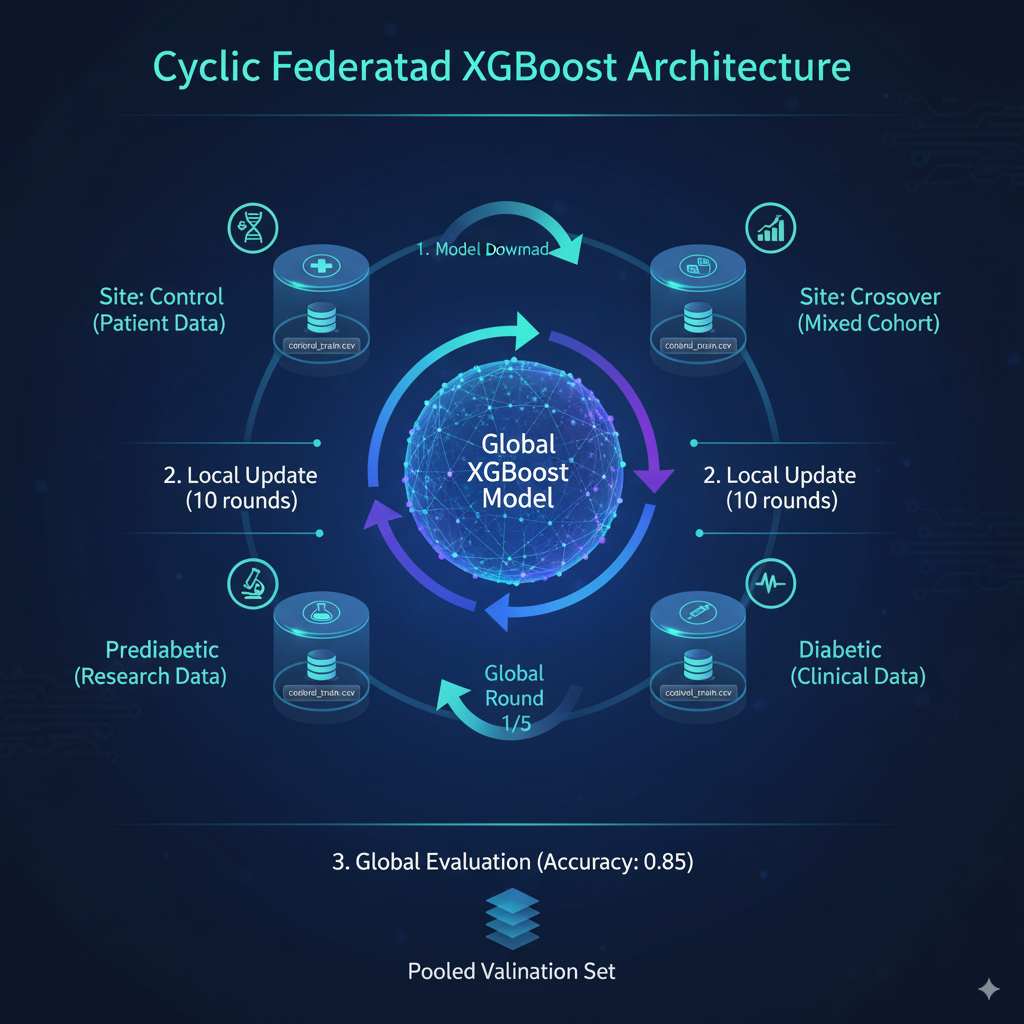

In [80]:
# -------------------------
# CONFIG
# -------------------------
CONFIG = {
    "DATA_ROOT": r"/kaggle/working/federated_data",  # <-- Windows absolute path
    "TEST_SIZE_PER_SITE": .2,
    "RANDOM_SEED": 42,
    "NUM_GLOBAL_ROUNDS": 10,
    "NUM_LOCAL_ROUNDS": 15,
    "EXCLUDE_COLS": {"id", "filename", "class", "label","ID","Label","Filename","Class",'SampleType'},
}

xgb_params = {
    "objective": "multi:softprob",
    "num_class": 4,
    "eval_metric": "mlogloss",
    "seed":42,
    #'verbose_eval':10
    
    #'learning_rate': 0.27939561800843504,'max_depth': 3, 'subsample': 0.8253979565746422,
            #'colsample_bytree': 0.5127079282603819,'min_child_weight': 4,
}

## 📂 Data Handling
1. **Site detection:** Each site is represented by a folder or CSV file in `DATA_ROOT`.  
2. **Label aggregation:** Global label space is constructed from all sites.  
3. **Feature selection:** Numeric columns are inferred automatically, excluding metadata columns.  
4. **Per-site preparation:**
   - Split into train/validation sets.
   - Convert to `xgb.DMatrix` format for efficiency.  

---

In [81]:
# -------------------------
# HELPERS
# -------------------------
def find_site_csv(site: str) -> str:
    """Return the CSV path for a site, handling Windows paths."""
    p1 = os.path.join(CONFIG["DATA_ROOT"], site, f"{site.lower()}_train.csv")
    p2 = os.path.join(CONFIG["DATA_ROOT"], f"{site.lower()}_train.csv")
    for p in [p1, p2]:
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"No CSV found for site '{site}'")

def infer_feature_cols(sites: List[str], exclude_cols: set) -> List[str]:
    for site in sites:
        p = find_site_csv(site)
        df = pd.read_csv(p)
        numeric_cols = df.select_dtypes(include=np.number).columns
        cols = [c for c in numeric_cols if c.strip().lower() not in exclude_cols]
        if cols:
            print(f"\nFeature columns from site '{site}': {cols}")
            print()
            return cols
    raise ValueError("Could not infer numeric feature columns from any site CSV.")

def prepare_site_data(site: str, feature_cols: List[str], le: LabelEncoder) -> Dict:
    p = find_site_csv(site)
    df = pd.read_csv(p)

    X = df[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0).values
    y = df["label"]

    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=CONFIG["TEST_SIZE_PER_SITE"],
        stratify=y, random_state=CONFIG["RANDOM_SEED"]
    )

    X_train_scaled = X_train
    X_val_scaled = X_val


    dtrain = xgb.DMatrix(X_train_scaled, label=y_train)
    dval = xgb.DMatrix(X_val_scaled, label=y_val)

    return {
        "dtrain": dtrain,
        "dval": dval,
        "n_train": len(y_train),
        "n_val": len(y_val),
        "X_val_scaled": X_val_scaled,
        "y_val": y_val,
    }

def create_pooled_validation(site_data: Dict[str, Dict]) -> xgb.DMatrix:
    X_list = [site_data[s]["X_val_scaled"] for s in site_data]
    y_list = [site_data[s]["y_val"] for s in site_data]
    X_pooled = np.vstack(X_list)
    y_pooled = np.concatenate(y_list)
    return xgb.DMatrix(X_pooled, label=y_pooled)

## 🔄 Federated Training Workflow
1. **Initialization:** Start with an empty global model.  
2. **Cyclic training:**  
   - For each global round, iterate over all sites.  
   - Each site trains locally on its `dtrain` data for 15 boosting rounds.  
   - The global model is updated sequentially with each site's contribution.  
3. **Validation:**  
   - After each global round, evaluate the updated global model on a **pooled validation set** (combined from all sites).  
   - Metric: **log loss** (`mlogloss`).  

---

## 📊 Output
- Training progress is logged per site and per global round.  
- After each round, pooled validation log loss is reported.  
- Final global model is saved as `global_bst.json` in `DATA_ROOT`.  

---

In [82]:
# -------------------------
# MAIN
# -------------------------
if __name__ == "__main__":
    # Detect sites (folders inside DATA_ROOT)
    SITES = sorted([
        name for name in os.listdir(CONFIG["DATA_ROOT"])
        if os.path.isdir(os.path.join(CONFIG["DATA_ROOT"], name))
           or os.path.isfile(os.path.join(CONFIG["DATA_ROOT"], f"{name}_train.csv"))
    ])
    print("Sites detected:", SITES)

    # Global labels
    all_labels = set()
    for site in SITES:
        df = pd.read_csv(find_site_csv(site))
        all_labels.update(df["label"]
                          #.astype(str)
                          .unique())
    GLOBAL_LABELS = sorted(list(all_labels))
    print("Global labels:", GLOBAL_LABELS,)

    # Feature columns
    feature_cols = infer_feature_cols(SITES, CONFIG["EXCLUDE_COLS"])

    # Per-site data
    site_data = {site: prepare_site_data(site, feature_cols, le) for site in SITES}
    for site in SITES:
        print(f"Site '{site}': n_train={site_data[site]['n_train']}, n_val={site_data[site]['n_val']}")

    # Pooled validation
    pooled_val = create_pooled_validation(site_data)
    print(f"Pooled validation set size: {pooled_val.num_row()}")

    # Cyclic federated training
    global_bst = None
    print("\nStarting cyclic federated training:")
    for gr in range(1, CONFIG["NUM_GLOBAL_ROUNDS"] + 1):
        print(f"\n=== Global round {gr}/{CONFIG['NUM_GLOBAL_ROUNDS']} ===")
        for site in SITES:
            client = site_data[site]
            print(f"Training on client '{site}' ({client['n_train']} samples)...")
            global_bst = xgb.train(
                xgb_params,
                client["dtrain"],
                num_boost_round=CONFIG["NUM_LOCAL_ROUNDS"],
                xgb_model=global_bst,
                evals=[(client["dval"], "val")],
                verbose_eval= 5,#False ,#10
            )

        # Evaluate on pooled validation
        #pooled_preds = global_bst.predict(pooled_val)
        #pooled_acc = (pooled_preds.argmax(axis=1) == pooled_val.get_label()).mean()
        #print(f"*** After global round {gr}: pooled validation accuracy = {pooled_acc:.4f}")
        
        pooled_preds = global_bst.predict(pooled_val)
        true_labels = pooled_val.get_label()
        
        if pooled_preds.ndim == 1:  # binary logistic
            pooled_logloss = log_loss(true_labels, pooled_preds)
        else:  # multiclass softprob
            pooled_logloss = log_loss(true_labels, pooled_preds)
        
        print(f"*** After global round {gr}: pooled validation log loss = {pooled_logloss:.4f}")


    # Save final model
    out_model_path = os.path.join(CONFIG["DATA_ROOT"], "global_bst.json")
    global_bst.save_model(out_model_path)
    print(f"\nGlobal model saved to {out_model_path}")

Sites detected: ['Control', 'Crossover', 'Diabetic', 'Prediabetic']
Global labels: [0, 1, 2, 3]

Feature columns from site 'Control': ['num_reads', 'avg_read_len', 'read_len_std', 'read_len_min', 'read_len_max', 'gc_content', 'gc_std', 'A', 'T', 'G', 'C', 'avg_entropy', 'avg_quality', 'std_quality', 'AA_freq', 'AC_freq', 'AG_freq', 'AT_freq', 'CA_freq', 'CC_freq', 'CG_freq', 'CT_freq', 'GA_freq', 'GC_freq', 'GG_freq', 'GT_freq', 'TA_freq', 'TC_freq', 'TG_freq', 'TT_freq', 'AAA_freq', 'AAC_freq', 'AAG_freq', 'AAT_freq', 'ACA_freq', 'ACC_freq', 'ACG_freq', 'ACT_freq', 'AGA_freq', 'AGC_freq', 'AGG_freq', 'AGT_freq', 'ATA_freq', 'ATC_freq', 'ATG_freq', 'ATT_freq', 'CAA_freq', 'CAC_freq', 'CAG_freq', 'CAT_freq', 'CCA_freq', 'CCC_freq', 'CCG_freq', 'CCT_freq', 'CGA_freq', 'CGC_freq', 'CGG_freq', 'CGT_freq', 'CTA_freq', 'CTC_freq', 'CTG_freq', 'CTT_freq', 'GAA_freq', 'GAC_freq', 'GAG_freq', 'GAT_freq', 'GCA_freq', 'GCC_freq', 'GCG_freq', 'GCT_freq', 'GGA_freq', 'GGC_freq', 'GGG_freq', 'GGT_fr


This setup simulates **federated learning** by cycling a shared XGBoost model across multiple sites, ensuring data remains local while improving the global model collaboratively.

# Inference

In [83]:
# 1. Load test data
df_test.columns = [c.strip() for c in df_test.columns]
df_test = df_test.loc[:, ~df_test.columns.str.startswith("Unnamed")]

# 2. Extract features
X_test = df_test[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0).values.astype(np.float32)

# 3. Scale with the SAME scaler as all training data
X_train_all = df_train[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0).values
X_test_scaled = X_test

# 4. Load trained global booster
bst = xgb.Booster()
bst.load_model(os.path.join(CONFIG["DATA_ROOT"],"global_bst.json"))

# 5. Predict probabilities
dtest = xgb.DMatrix(X_test_scaled)
proba = bst.predict(dtest)  # shape: (n_samples, n_classes)

# 6. Map back to original labels
class_labels = le.inverse_transform(np.arange(4))
probs_df = pd.DataFrame(proba, columns=class_labels)

# 7. Keep filenames if present
if "filename" in df_test.columns:
    probs_df.insert(0, "filename", df_test["filename"])

# 8. Optional: clean filenames
if "filename" in probs_df.columns:
    probs_df["filename"] = probs_df["filename"].str.replace(".fastq", "", regex=False)

# 9. Save
probs_df.to_csv("federated.csv", index=False)
display(probs_df.shape, probs_df.head())

(1068, 5)

,filename,Mouth,Nasal,Skin,Stool
0,ID_ABHFUP,1.161993e-06,0.999998,1.014300e-06,1.703027e-07
1,ID_ADBLNY,6.955801e-07,0.999999,4.724163e-07,1.077317e-07
2,ID_AFAEMB,9.999026e-01,0.000017,7.829157e-05,2.119971e-06
3,ID_AFBBWK,9.999958e-01,0.000001,2.930097e-06,9.893794e-08
4,ID_AGHEZK,9.997749e-01,0.000020,2.040764e-04,1.506846e-06


# End